In [ ]:
import os
import math
import gc
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from skimage.filters import median
from skimage.morphology import disk
import matplotlib.patches as patches
import torch.nn as nn


from src.Elements import Elements
from src.models import create_model 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
directories = [Path("data/model_weights/classification")]

objects = [
    # ("matka_boska", torch.tensor(np.load("data/objects/processed/matka_boska_1x1_patches_discrete.npz", allow_pickle=True)["e_xy"], dtype=torch.float)),
    # ("matka_boska_discrete", torch.tensor(np.load("data/objects/processed/matka_boska_1x1_patches.npz", allow_pickle=True)["e_xy"], dtype=torch.float)),
    # ("pigment_palette", torch.tensor(np.load("data/objects/processed/pigment_palette_1x1_patches.npz", allow_pickle=True)["e_xy"], dtype=torch.float)),
    # ("pigment_palette_discrete", torch.tensor(np.load("data/objects/processed/pigment_palette_1x1_patches_discrete.npz", allow_pickle=True)["e_xy"], dtype=torch.float)),
    # ("sobieski", torch.tensor(np.load("data/objects/processed/sobieski_1x1_patches.npz", allow_pickle=True)["e_xy"], dtype=torch.float)),
    # ("sobieski_discrete", torch.tensor(np.load("data/objects/processed/sobieski_1x1_patches_discrete.npz", allow_pickle=True)["e_xy"], dtype=torch.float)),
    # ("gasecki_discrete", torch.tensor(np.load("data/objects/processed/gasecki_1x1_patches_discrete.npz", allow_pickle=True)["e_xy"], dtype=torch.float)),
    # ("gasecki", torch.tensor(np.load("data/objects/processed/gasecki_1x1_patches.npz", allow_pickle=True)["e_xy"], dtype=torch.float)),
    ("bohomaz_discrete", torch.tensor(np.load("data/objects/bohomaz/Bohomaz_data_corr_total.npz", allow_pickle=True)["E_xy"], dtype=torch.float))
]

bohomaz = objects[-1][1]
max_vals = bohomaz.abs().max(dim=-1, keepdim=True).values
cube_normalized = bohomaz / (max_vals + 1e-8) 
objects[-1] = (objects[-1][0], cube_normalized)

pigment_vs_pigment = torch.tensor(np.load("data/objects/pigment_vs_pigment.npy", allow_pickle=True), dtype=torch.float)
pigment_vs_pigment_noise = torch.tensor(np.load("data/objects/pigment_vs_pigment_noise.npy", allow_pickle=True), dtype=torch.float)
pigment_vs_pigment_noise_mh = torch.tensor(np.load("data/objects/pigment_vs_pigment_noise_mh.npy", allow_pickle=True), dtype=torch.float)

bboxes = {
    'mn': [(9, 25, 9, 25), (9, 25, 97, 113)],
    'fe': [(9, 25, 9, 25), (53, 69, 31, 47)],
    'ca': [(9, 25, 31, 47), (9, 25, 53, 69), (9, 25, 75, 91)],
    'zn': [(9, 25, 31, 47), (9, 25, 53, 69), (9, 25, 75, 91), (97, 113, 97, 113)],
    's': [(9, 25, 53, 69), (31, 47, 9, 25), (31, 47, 97, 113), (53, 69, 75, 91), (97, 113, 53, 69), (97, 113, 75, 91)],
    'as': [(9, 25, 53, 69), (31, 47, 97, 113)],
    'pb': [(9, 25, 75, 91), (75, 91, 9, 25), (75, 91, 53, 69)],
    'hg': [(31, 47, 9, 25)],
    'wood': [(31, 47, 31, 47)],
    'cr': [(31, 47, 53, 69)],
    'ti': [(31, 47, 75, 91)],
    'si': [(53, 69, 9, 25), (53, 69, 53, 69)],
    'zr': [(53, 69, 9, 25)],
    'na': [(53, 69, 53, 69)],
    'al': [(53, 69, 53, 69), (75, 91, 97, 113)],
    'k': [(53, 69, 75, 91), (53, 69, 97, 113)],
    'cd': [(53, 69, 75, 91)],
    'co': [(53, 69, 97, 113), (97, 113, 31, 47)],
    'sn': [(75, 91, 9, 25)],
    'cu': [(75, 91, 31, 47), (97, 113, 97, 113)],
    'ag': [(75, 91, 75, 91)],
    'si': [(53, 69, 9, 25), (53, 69, 53, 69)],
    'zn': [(9, 25, 31, 47), (9, 25, 53, 69), (9, 25, 75, 91), (97, 113, 97, 113), (97, 113, 9, 25)],
    'ba': [(97, 113, 53, 69)],
    'au': [(97, 113, 75, 91)]
}

def infer_model(model, e_xy, batch_size=128):
    H, W, C = e_xy.shape
    e_xy_flat = e_xy.view(-1, C)
    outputs = []

    with torch.no_grad():
        for i in range(0, len(e_xy_flat), batch_size):
            print(f"Batch {i // batch_size + 1}")
            batch = e_xy_flat[i:i + batch_size].unsqueeze(1)
            out = model(batch)
            outputs.append(out)

    return torch.cat(outputs, dim=0).view(H, W, -1).cpu()

def plot_output_maps(outputs, object_name, save_path, k=5, filtered=False, custom_ticks=False):
    depth = outputs.shape[2]
    outputs[outputs < 0.5] = 0
    outputs[outputs > 0] = 1

    n_cols = 4
    n_rows = math.ceil(depth / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.5))
    axes = axes.flatten()
    im = None

    for i in range(depth):
        ax = axes[i]

        im = ax.imshow(outputs[:,:,i], cmap='binary_r', aspect='auto', vmin=0, vmax=1)


        try:
            element = Elements.NUM2SYMBOL[i]
            title = f'{i + 1}: {element.capitalize()}'
        except IndexError:
            element = "wood" 
            title = f'{i + 1}: {element}'
        ax.set_title(title)

        if custom_ticks:
            ticks = list(Elements.LINES.keys())
            tick_pos = np.arange(0, len(ticks) * 20, 20)
            ax.set_xticks(tick_pos)
            ax.set_xticklabels(ticks, ha='left', fontsize=9, rotation=45)
            ax.set_yticks(tick_pos + 5)
            ax.set_yticklabels(ticks, fontsize=9)
            ax.xaxis.set_ticks_position('top')
            ax.tick_params(axis='x', length=0)
            ax.tick_params(axis='y', length=0)
        
        if "pigment_palette" in object_name:
            for (x1, x2, y1, y2) in bboxes[element]:
                width, height = y2 - y1 + 4, x2 - x1 + 4
                rect = patches.Rectangle((y1-2, x1-2), width, height, linewidth=3, edgecolor='#FF4FFF', facecolor='none')
                ax.add_patch(rect)
        elif "pigment_vs_pigment" in object_name:
            pass
        else:
            ax.set_xticks([])
            ax.set_yticks([])

    for j in range(depth, len(axes)):
        fig.delaxes(axes[j])

    if im:
        if custom_ticks:
            # Adjust layout to make room for vertical colorbar
            fig.subplots_adjust(right=0.88, hspace=0.4)
            cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
            cbar = fig.colorbar(im, cax=cbar_ax)
        else:
            # Use tight layout with space for colorbar
            fig.subplots_adjust(wspace=0.15, hspace=0.2, right=0.85)
            cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.7])
            cbar = fig.colorbar(im, cax=cbar_ax)

        cbar.set_label("Relative counts")

    # Save figure
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, bbox_inches='tight')
    plt.close(fig)


def evaluate_model_on_object(object_name: str, e_xy: torch.Tensor, model_paths: list[Path], output_root: Path):
    for model_path in model_paths:
        gc.collect()
        print(f"Evaluating {object_name} with model {model_path.name}")
        model = torch.load(model_path, weights_only=False).to(device)
        model = nn.Sequential(model, nn.Sigmoid())
        model.eval()
        model_name = model_path.stem

        outputs = infer_model(model, e_xy)
        save_path = output_root / object_name / f"{model_name}.png"

        if object_name in ["pigment_vs_pigment", "pigment_vs_pigment_noise", "pigment_vs_pigment_noise_mh"]:
            plot_output_maps(outputs, object_name, save_path, filtered=False, custom_ticks=True)
        else:
            plot_output_maps(outputs, object_name, save_path, filtered=False)


def main():

    for object_name, e_xy in objects + [("pigment_vs_pigment", pigment_vs_pigment), ("pigment_vs_pigment_noise", pigment_vs_pigment_noise), ("pigment_vs_pigment_noise_mh", pigment_vs_pigment_noise_mh)]:
        gc.collect()
        for directory in directories:
            # model_paths = [directory / filename for filename in os.listdir(directory) if (directory / filename).is_file()]
            model_paths = [directory / filename for filename in os.listdir(directory) if (directory / filename).is_file()]

            output_root = Path("data", "evaluation", "classification")

            e_xy = e_xy.to(device)
            evaluate_model_on_object(object_name, e_xy, model_paths, output_root)
        del e_xy
                            
print(device)
main()                            

KeyError: 'e_xy is not a file in the archive'

In [2]:
obj = torch.tensor(np.load("data/objects/bohomaz/Bohomaz_data_corr_total.npz", allow_pickle=True)["E_xy"], dtype=torch.float)

torch.Size([228, 224, 4096])


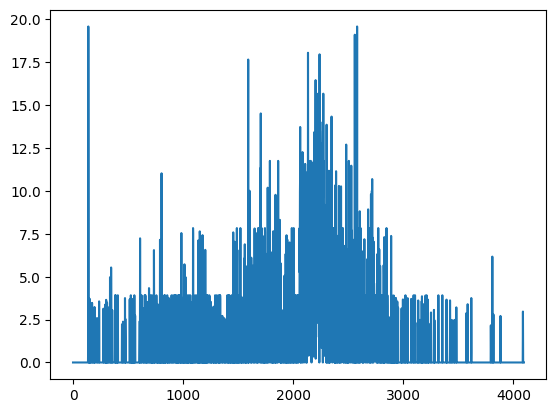

In [6]:
print(obj.shape)

plt.plot(obj[20, 20])